In [3]:
# load data
# %run ../../../machine_learning/load_untargeted_data.py -d "/mnt/c/Users/ETTINA03/NYU Langone Health Dropbox/April Jauhal/Shenhav_Lab" 

%run ../../../machine_learning/load_untargeted_data.py -d "C:\\Users\\ds7014\\NYU Langone Health Dropbox\\Daniel Sunko\\Shenhav_Lab" 

loading metadata
loading data


C:\Users\ds7014\NYU Langone Health Dropbox\Daniel Sunko\Shenhav_Lab\IMiC\Code\machine_learning\load_untargeted_data.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Child_month3_anthro.rename(columns={'WAZ': 'WAZ_M03', 'HAZ': 'HAZ_M03', 'WHZ': 'WHZ_M03', 'SUBJIDO': 'SubjectID'}, inplace=True)


(843, 37072)
(399, 60609)
(300, 60609)
(393, 60609)
reading keys
reading Sapient top metabolites


In [4]:
# load functions
%run ../../../machine_learning/ml_functions.py

C:\Users\ds7014\NYU Langone Health Dropbox\Daniel Sunko\Shenhav_Lab\IMiC\Code\machine_learning\ml_functions.py:1222: SyntaxWarning: invalid escape sequence '\p'
  label=f"{type} ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
C:\Users\ds7014\NYU Langone Health Dropbox\Daniel Sunko\Shenhav_Lab\IMiC\Code\machine_learning\ml_functions.py:1297: SyntaxWarning: invalid escape sequence '\p'
  label=f"{plot_names[n]} (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),


In [5]:
# Data pre-processing
vital_preproc_hits=pd.merge(vital_full_BM_df_filt.rename(columns={'SampleID': 'sample_ID'}, inplace=False)[['sample_ID', 'SubjectID', 'Timepoint']], vital_1to1_preproc, how='right', on='sample_ID')
misame_preproc_hits=pd.merge(misame_full_BM_df_filt.rename(columns={'SampleID': 'sample_ID'}, inplace=False)[['sample_ID', 'SubjectID', 'Timepoint']], misame_1to1_preproc, how='right', on='sample_ID')

vital_full_BM_df_filt=vital_full_BM_df_filt.assign(postnatal_BEP=np.where(vital_full_BM_df_filt['ARMCD'].isin([2, 3]), 1, 0))
misame_full_BM_df_filt = misame_full_BM_df_filt.assign(postnatal_BEP=np.where(misame_full_BM_df_filt['ARMCD'].isin([2, 4]), 1, 0))

vital_WAZM04_meta_for_ML=pd.merge(vital_full_BM_df_filt[['SubjectID', 'WAZ_M04_binary_bins','WHZ_M04_binary_bins', 'WAZ_M04', 'WHZ_M04','WHZ_M03','WAZ_traj','WAZ_M4_M0_falter_binary_bins2','WAZ_M4_M0_thrive_binary_bins2','Azithromycin_binary']].drop_duplicates(), timepoint_col_distribute(vital_preproc_hits), how='inner', on='SubjectID')
misame_WAZM04_meta_for_ML=pd.merge(misame_full_BM_df_filt[['SubjectID', 'WAZ_M04_binary_bins','WHZ_M04_binary_bins',  'WAZ_M04', 'WHZ_M04','WHZ_M03', 'WAZ_traj','WAZ_M4_M0_falter_binary_bins2','WAZ_M4_M0_thrive_binary_bins2']].drop_duplicates(), timepoint_col_distribute(misame_preproc_hits), how='inner', on='SubjectID')

In [6]:
# Set thresholds for plotting
child_bottom_limit = -1
child_top_limit = 0

vital_bottom_limit = -2
vital_top_limit = -1

misame_bottom_limit = -1
misame_top_limit = 0

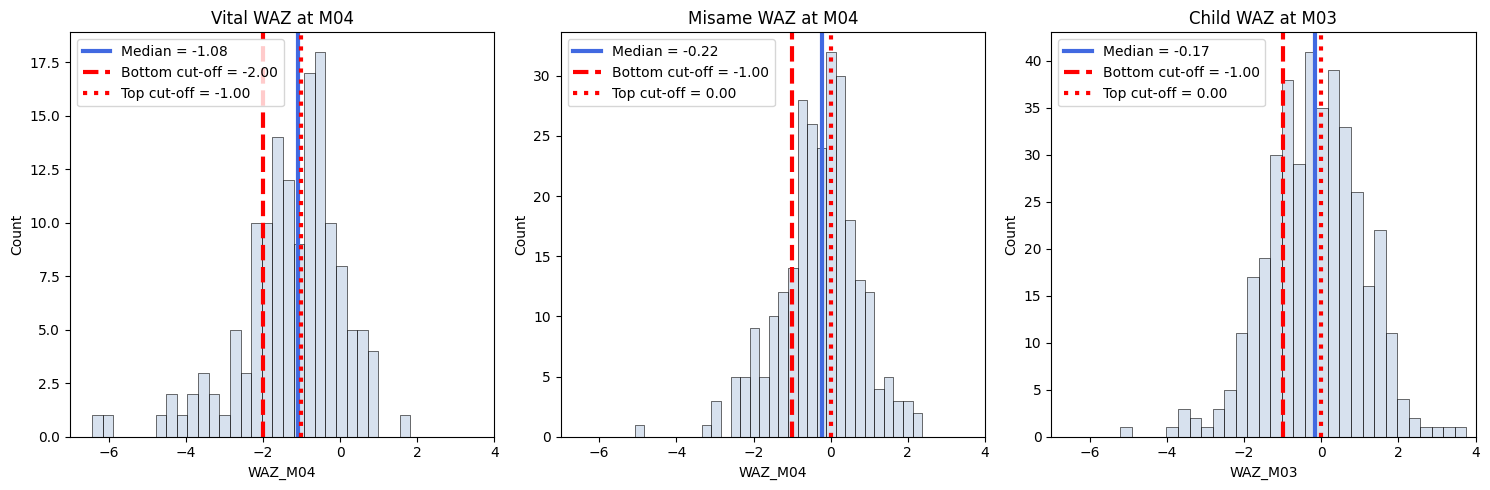

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

limit_color = 'pink'

sns.histplot(data=vital_WAZM04_meta_for_ML, x='WAZ_M04', bins=30, ax=axes[0], 
             alpha = 0.5, linewidth=0.4, color='lightsteelblue')
median_val = vital_WAZM04_meta_for_ML['WAZ_M04'].median()
axes[0].axvline(median_val, color='royalblue', 
             #linestyle=(5,(10,3)), 
             linewidth=3, label=f'Median = {median_val:.2f}')
axes[0].axvline(vital_bottom_limit, color='red', linestyle='--', linewidth=3, label=f'Bottom cut-off = {vital_bottom_limit:.2f}')
axes[0].axvline(vital_top_limit, color='red', linestyle='dotted', linewidth=3, label=f'Top cut-off = {vital_top_limit:.2f}')
axes[0].set_xlim(-7, 4)
axes[0].set_title("Vital WAZ at M04")
axes[0].legend()


# Second plot
sns.histplot(data=misame_WAZM04_meta_for_ML, x='WAZ_M04', bins=30, ax=axes[1],
             alpha = 0.5, linewidth=0.4, color='lightsteelblue')
median_val = misame_WAZM04_meta_for_ML['WAZ_M04'].median()
axes[1].axvline(median_val, color='royalblue',linewidth=3, label=f'Median = {median_val:.2f}')
axes[1].axvline(misame_bottom_limit, color='red', linestyle='--', linewidth=3, label=f'Bottom cut-off = {misame_bottom_limit:.2f}')
axes[1].axvline(misame_top_limit, color='red', linestyle='dotted', linewidth=3, label=f'Top cut-off = {misame_top_limit:.2f}')
axes[1].set_xlim(-7, 4)
axes[1].set_title("Misame WAZ at M04")
axes[1].legend()


# Third plot
sns.histplot(data=child_meta_for_ML, x='WAZ_M03', bins=30, ax=axes[2],
             alpha = 0.5, linewidth=0.4, color='lightsteelblue')
median_val = child_meta_for_ML['WAZ_M03'].median()
axes[2].axvline(median_val, color='royalblue',linewidth=3, label=f'Median = {median_val:.2f}')
axes[2].axvline(child_bottom_limit, color='red', linestyle='--', linewidth=3, label=f'Bottom cut-off = {child_bottom_limit:.2f}')
axes[2].axvline(child_top_limit, color='red', linestyle='dotted', linewidth=3, label=f'Top cut-off = {child_top_limit:.2f}')
axes[2].set_xlim(-7, 4)
axes[2].set_title("Child WAZ at M03")
axes[2].legend()

plt.tight_layout()
plt.savefig('hist_fig.pdf', dpi=600)